In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

df = pd.read_parquet('../data/fe_train_final.parquet')

target = 'TARGET'
drop_cols = ['SK_ID_CURR', target]
X = df.drop(columns=drop_cols)
y = df[target]

cat_cols = X.select_dtypes(include='object').columns.tolist()
X = X.drop(columns=cat_cols)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 50,
    'scale_pos_weight': 11,
    'verbosity': -1,
    'n_jobs': -1,
}

model = lgb.LGBMClassifier(**params, n_estimators=270)
model.fit(X, y)
print("Model trained.")

Model trained.


In [2]:
# Sample 2000 rows — enough for reliable SHAP, won't crash
X_sample = X.sample(2000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2000, 184)


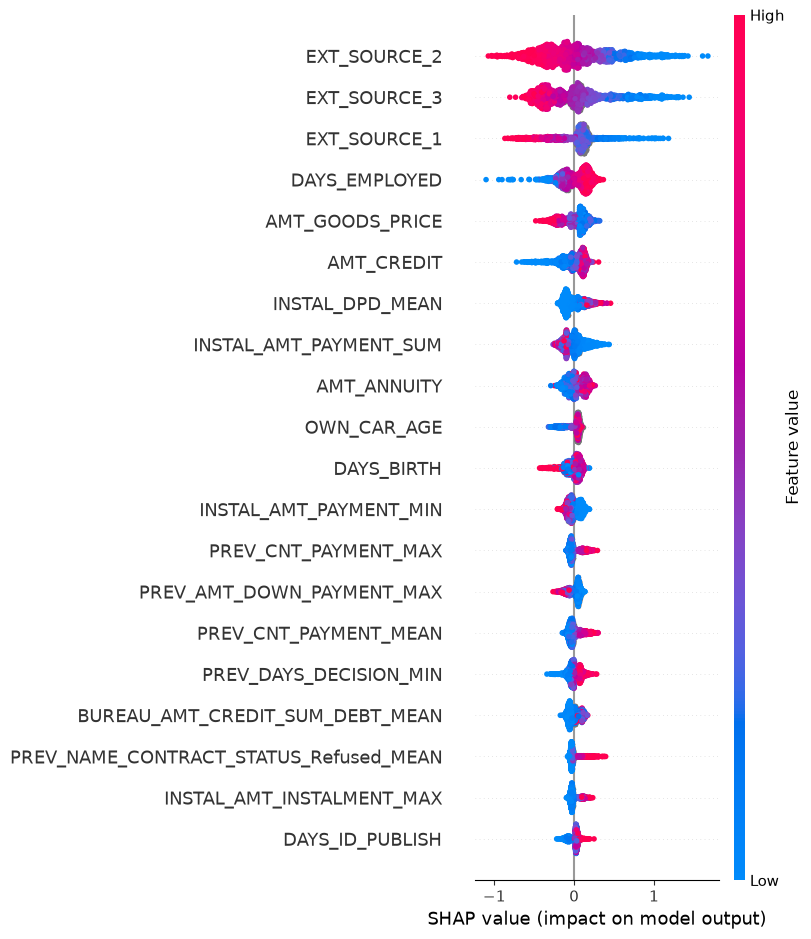

In [3]:
plt.figure()
shap.summary_plot(shap_values, X_sample, max_display=20, show=True)

=== Defaulter Explanation ===


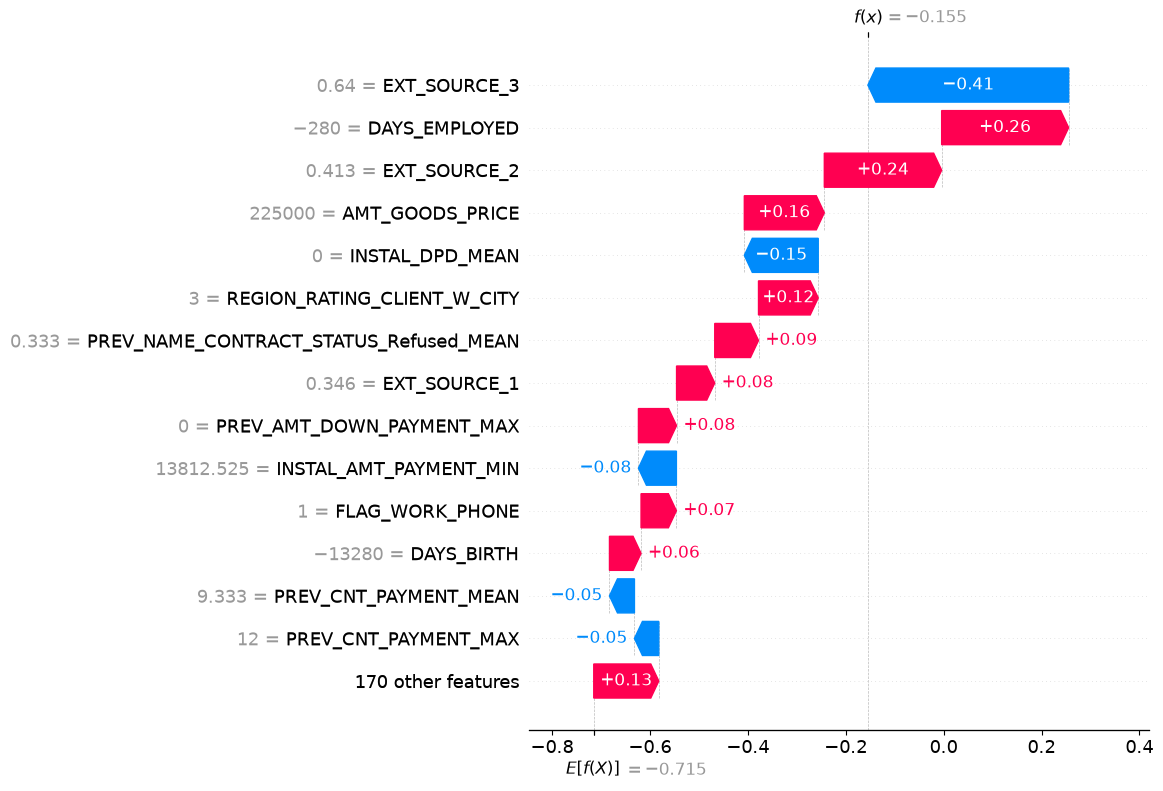

=== Safe Customer Explanation ===


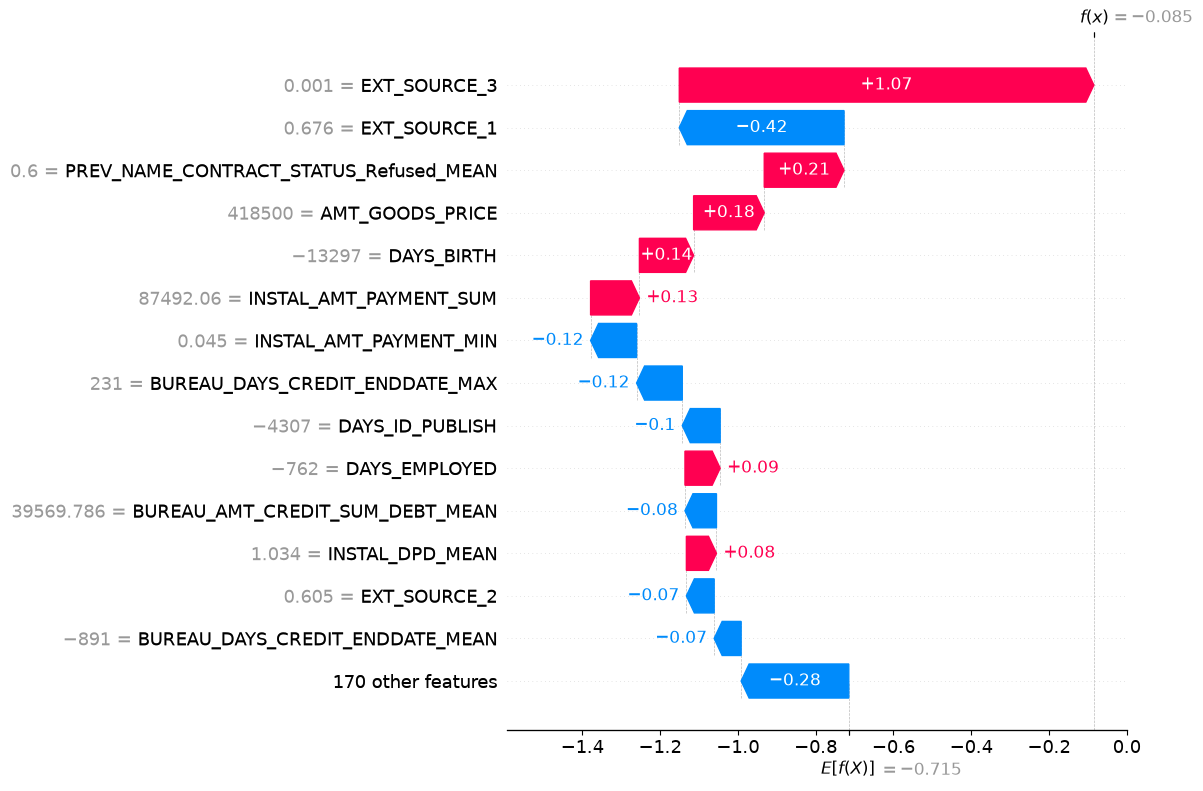

In [4]:
# Find a defaulter and a safe customer in our sample
sample_with_target = X_sample.copy()
sample_with_target['TARGET'] = y.loc[X_sample.index].values

defaulter_idx = sample_with_target[sample_with_target['TARGET'] == 1].index[0]
safe_idx = sample_with_target[sample_with_target['TARGET'] == 0].index[0]

defaulter_pos = X_sample.index.get_loc(defaulter_idx)
safe_pos = X_sample.index.get_loc(safe_idx)

explainer_v2 = shap.TreeExplainer(model)

print("=== Defaulter Explanation ===")
shap.plots.waterfall(explainer_v2(X_sample)[defaulter_pos], max_display=15, show=True)

print("=== Safe Customer Explanation ===")
shap.plots.waterfall(explainer_v2(X_sample)[safe_pos], max_display=15, show=True)

## SHAP Findings

- **EXT_SOURCE 1/2/3** dominate individual predictions — external credit score is the strongest signal
- **DAYS_EMPLOYED** short employment duration increases default risk significantly  
- **PREV_NAME_CONTRACT_STATUS_Refused** — prior loan refusals are a strong risk indicator
- Waterfall plots enable loan-level explanations — critical for regulatory compliance